<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage3/Day_1/Day1_Lab2_CNN_AlexNet_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)

# Image Classification using CNN: CIFAR10
- **Images**: 60,000 color images of size **(32x32)** in **10 categories**, with 6000 images per class. There are 50000 training images and 10000 test images.
- **Classes**: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck.
- **Shape**: `(batch_size, 3, 32, 32)` → 3 channels (RGB).
  
![CIFAR-10 image](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)


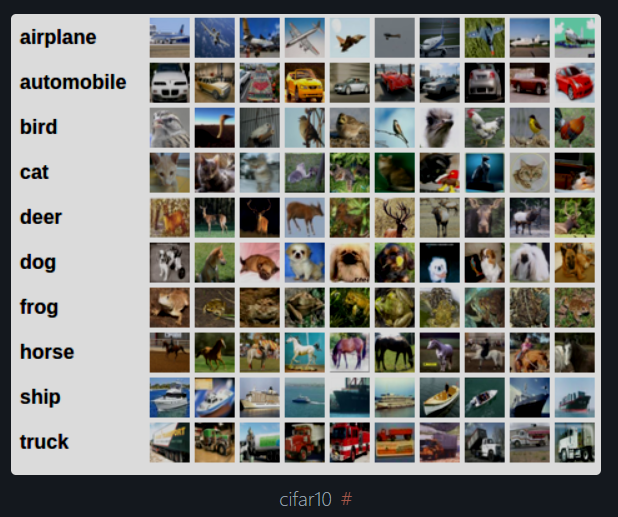

## 1️⃣ Dataset Class

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# Define transformations (convert to tensor)                         ## Will study in-depth in a next lab
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load CIFAR-10 dataset
train_dataset = CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = CIFAR10(root="./data", train=False, transform=transform, download=True)

# Create DataLoaders
# (The Dataset Class loads only one sample at a time. We pass it to dataloader to read batch_size of images at a time)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # num_workers --> cpu
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
# if i have an error that "cuda out of memory" then I need to minmize the batch_size
# The dataset gives 1 sample at a time.
# The DataLoader groups them into batches.

# Check dataset size
print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Training samples: 50000, Testing samples: 10000


### Let's display some images

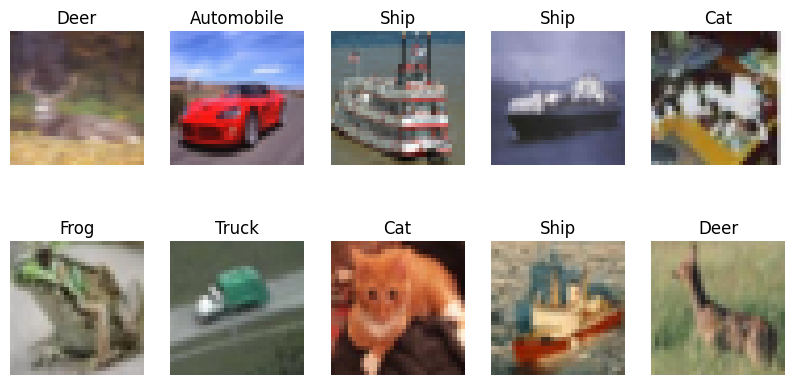

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)
# next() fetches one batch
# Now:
# images.shape = (32, 3, 32, 32)
# labels.shape = (32,)


# CIFAR-10 class names
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Show images
fig, axes = plt.subplots(2, 5, figsize=(10, 5)) # for 30 images change 2, 5 --> (5, 6, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = np.transpose(img.numpy(), (1, 2, 0))  # Convert (C, H, W) to (H, W, C)
    # permute(0, 2, 3, 1)
    # PyTorch format: (C, H, W) = (3, 32, 32)
    # Matplotlib expects: (H, W, C) = (32, 32, 3)


    ax.imshow(img)
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")

plt.show()

In [ ]:
print("Shape of one image tensor:", images[0].shape)  # Expected: (3, 32, 32)

Shape of one image tensor: torch.Size([3, 32, 32])


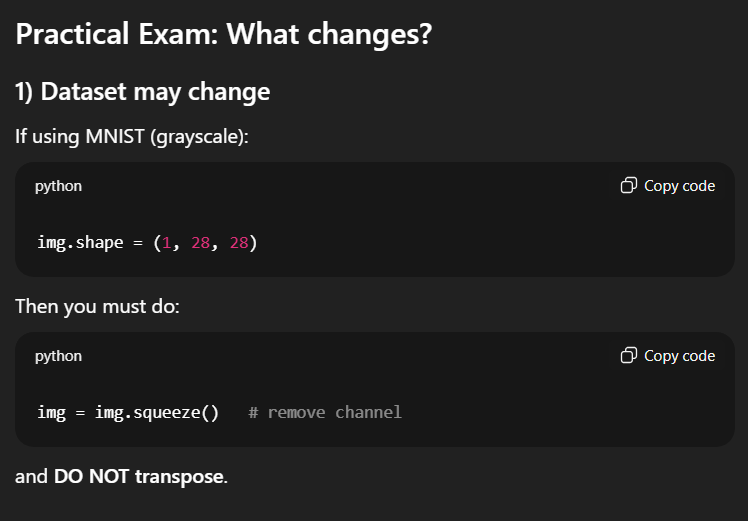

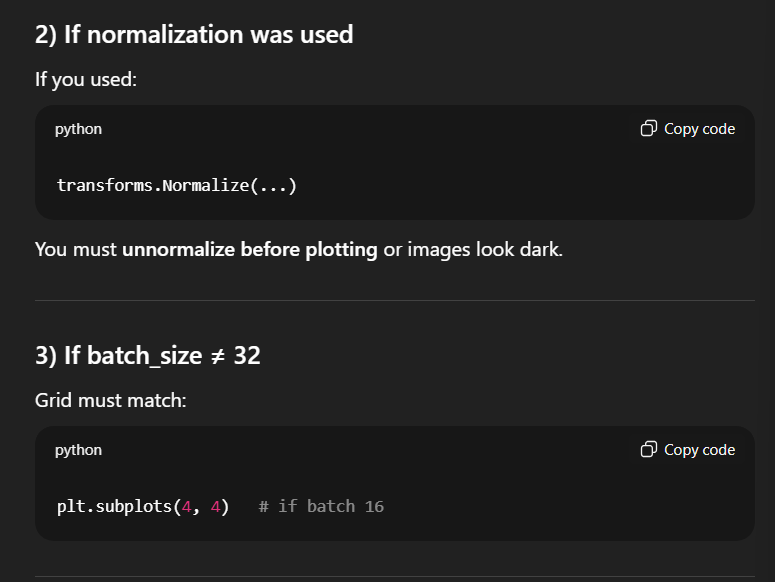

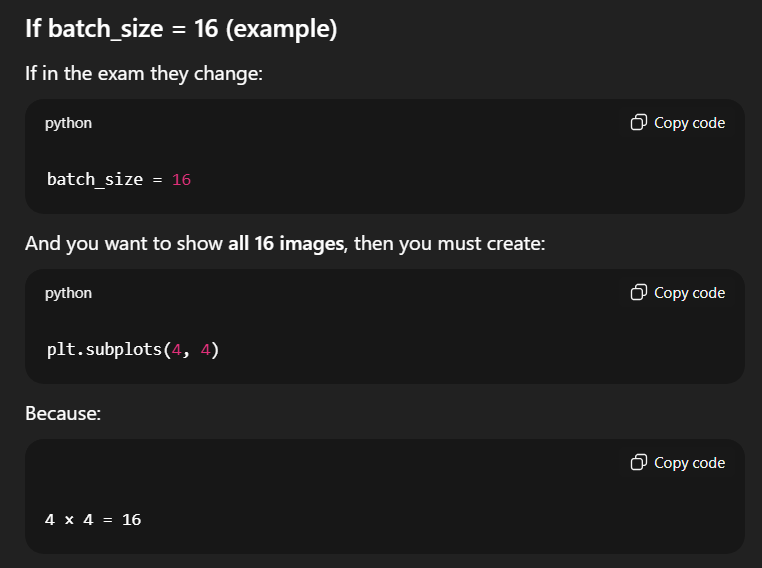

## 2️⃣ Model Class

In [ ]:
import torch.nn as nn
import torch

# Define the CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Activation
        self.relu = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # # 🔥 Add here
        # self.gap = nn.AdaptiveAvgPool2d((1, 1))


        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes for CIFAR-10

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))  # (Batch, 16, 16, 16)
        x = self.pool(self.relu(self.conv2(x)))  # (Batch, 32, 8, 8)
        x = self.pool(self.relu(self.conv3(x)))  # (Batch, 64, 4, 4)

        # Flatten
        x = x.view(x.size(0), -1)  # (Batch, 64*4*4)

        print('Right before flatten: ', x.shape)

        # # 🔥 Put here
        # x = self.gap(x)        # (Batch, 64, 1, 1)
        # x = x.flatten(1)      # (Batch, 64)


        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Logits

        return x                # Although this is a classification problem, we didn't apply softmax. Do you know why?👀 (Hint: CrossEntropyLoss has something to do here👀)
        # Because CrossEntropyLoss internally applies LogSoftmax, so the model should output raw logits to avoid applying Softmax twice.

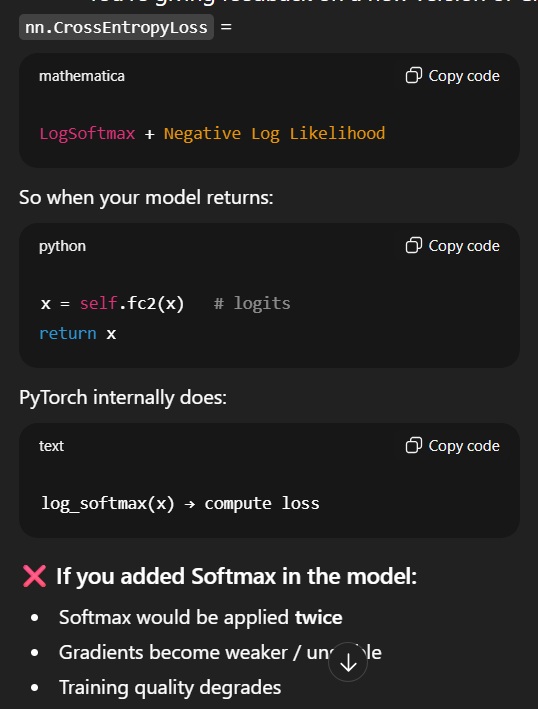

In [ ]:
class AlexNet32(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet32, self).__init__()
        self.features = nn.Sequential( # nn.Sequential lets you stack layers in order. The output of one goes into the next automatically.
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 96, kernel_size=11, stride=2, padding=5),  # Output: 96 x 16 x 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # Output: 96 x 7 x 7

            nn.Conv2d(96, 256, kernel_size=5, padding=2),          # Output: 256 x 7 x 7
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # Output: 256 x 3 x 3

            nn.Conv2d(256, 384, kernel_size=3, padding=1),         # Output: 384 x 3 x 3
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),         # Output: 384 x 3 x 3
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),         # Output: 256 x 3 x 3
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=1)                   # Output: 256 x 2 x 2
        )

        self.classifier = nn.Sequential( # Another stack of layers, but now for classification.
            nn.Dropout(), # Randomly zeros some activations during training to reduce overfitting
            nn.Linear(256 * 2 * 2, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## 3️⃣ Training and Validation Loops

In [ ]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)


        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)  # Get class with highest probability
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()

            # Compute accuracy
            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)  # Get predicted class
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy


## 4️⃣ Running Training

In [ ]:
import torch.optim as optim

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 1563/1563 [00:13<00:00, 116.34it/s]


Epoch 1/10: Train Loss=1.5366, Train Accuracy=43.84%, Val Loss=1.2705, Val Accuracy=53.43%


100%|██████████| 1563/1563 [00:12<00:00, 127.32it/s]


Epoch 2/10: Train Loss=1.1896, Train Accuracy=57.47%, Val Loss=1.1081, Val Accuracy=60.50%


100%|██████████| 1563/1563 [00:12<00:00, 126.39it/s]


...

Epoch 8/10: Train Loss=0.6847, Train Accuracy=75.90%, Val Loss=0.9014, Val Accuracy=69.19%


100%|██████████| 1563/1563 [00:12<00:00, 126.38it/s]


Epoch 9/10: Train Loss=0.6431, Train Accuracy=77.33%, Val Loss=0.8829, Val Accuracy=70.40%


100%|██████████| 1563/1563 [00:12<00:00, 124.44it/s]


Epoch 10/10: Train Loss=0.6060, Train Accuracy=78.59%, Val Loss=0.8613, Val Accuracy=71.43%


### Plot loss and some predictions

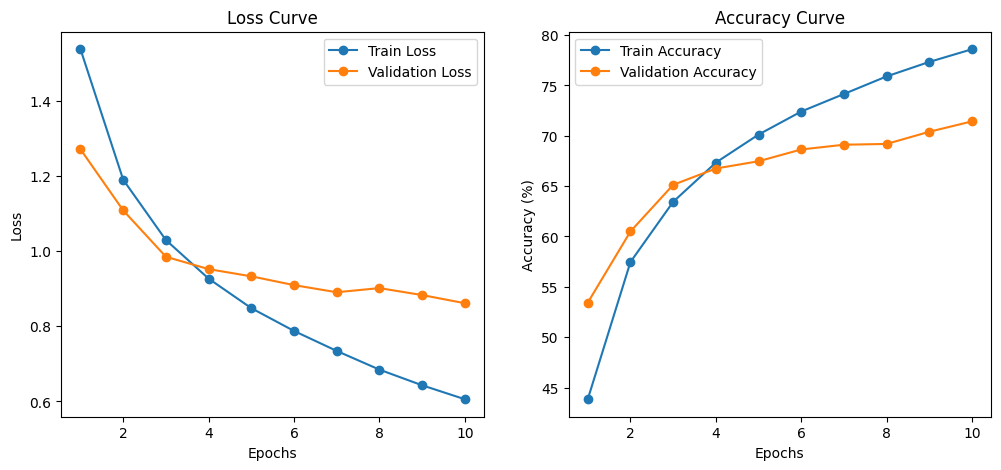

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


# **1) Loss Curve (left)**

**What you see:**

Training loss goes down strongly from about ~1.5 to ~0.6 ✅

Validation loss goes down at first, then decreases slowly and almost “flattens” around ~0.9 ✅

**Meaning:**

The model is learning (loss decreasing).

But the model improves on training faster than validation.

# **2) Accuracy Curve (right)**

**What you see:**

Training accuracy rises a lot (~44% → ~79%) ✅

Validation accuracy rises too (~53% → ~71%) ✅ but slower and starts plateauing.

**Meaning:**

Generalization is improving (validation accuracy increases).

The gap between training and validation accuracy becomes larger → mild overfitting is starting.

# **✅ One perfect exam explanation**

**You can write/say:**

“Training loss decreases steadily and training accuracy increases, so the model is learning. Validation loss decreases then plateaus, and validation accuracy improves but slower, which suggests the model starts to overfit slightly after a few epochs. Early stopping or regularization could help.”

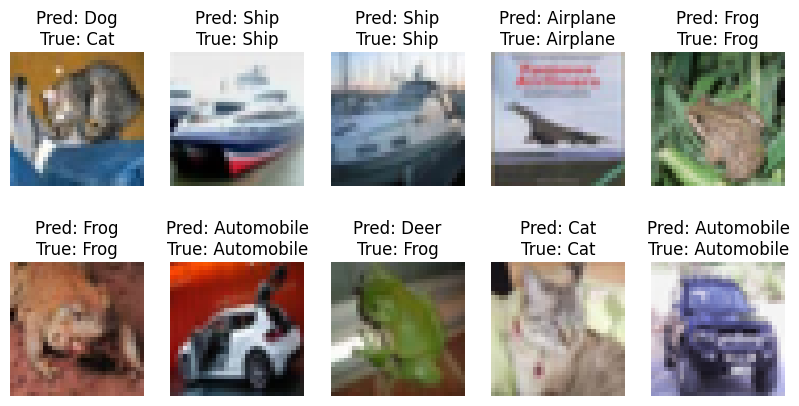

In [ ]:
import numpy as np

# Function to display images with predicted labels
def show_predictions(model, dataloader, device, num_images=10):
    model.eval()  # Set to evaluation mode
    images, labels = next(iter(dataloader))  # Get a batch
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():  # Disable gradient computation
        outputs = model(images) # Forward pass
        predictions = outputs.argmax(dim=1)  # Get predicted class

    # CIFAR-10 class names
    classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

    # Plot images with predictions
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat[:num_images]):
        img = images[i]
        img = np.transpose(img.cpu().numpy(), (1, 2, 0))  # Convert to (H, W, C)

        ax.imshow(img)
        ax.set_title(f"Pred: {classes[predictions[i].item()]}\nTrue: {classes[labels[i].item()]}")
        ax.axis("off")

    plt.show()

# Show predictions
show_predictions(model, test_loader, device)


## 4️⃣ Running Training On AlexNet


In [ ]:
import torch.optim as optim

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelAlex = AlexNet32(num_classes=10).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class Classification loss (Input: Logits, not probabilities)
optimizer = optim.Adam(modelAlex.parameters(), lr=0.001)  # Adam optimizer
num_epochs = 10 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(modelAlex, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(modelAlex, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


100%|██████████| 1563/1563 [00:29<00:00, 53.52it/s]


Epoch 1/10: Train Loss=2.1553, Train Accuracy=15.37%, Val Loss=1.8091, Val Accuracy=27.53%


100%|██████████| 1563/1563 [00:31<00:00, 50.40it/s]


Epoch 2/10: Train Loss=1.7547, Train Accuracy=32.50%, Val Loss=1.6541, Val Accuracy=36.31%


100%|██████████| 1563/1563 [00:29<00:00, 53.47it/s]


...

Epoch 8/10: Train Loss=1.3155, Train Accuracy=53.51%, Val Loss=1.3488, Val Accuracy=51.64%


100%|██████████| 1563/1563 [00:29<00:00, 52.81it/s]


Epoch 9/10: Train Loss=1.2756, Train Accuracy=55.16%, Val Loss=1.3118, Val Accuracy=53.49%


100%|██████████| 1563/1563 [00:29<00:00, 53.33it/s]


Epoch 10/10: Train Loss=1.2431, Train Accuracy=56.23%, Val Loss=1.3321, Val Accuracy=52.71%


### Plot loss and some predictions

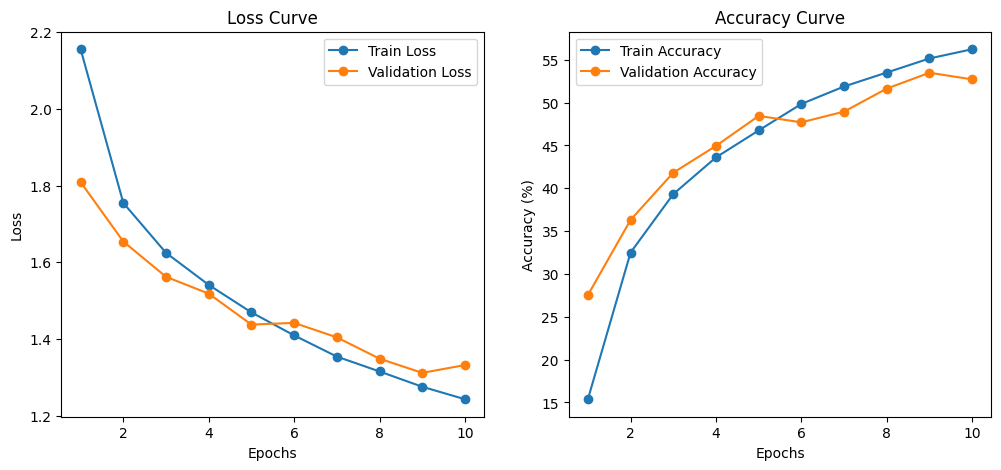

In [ ]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


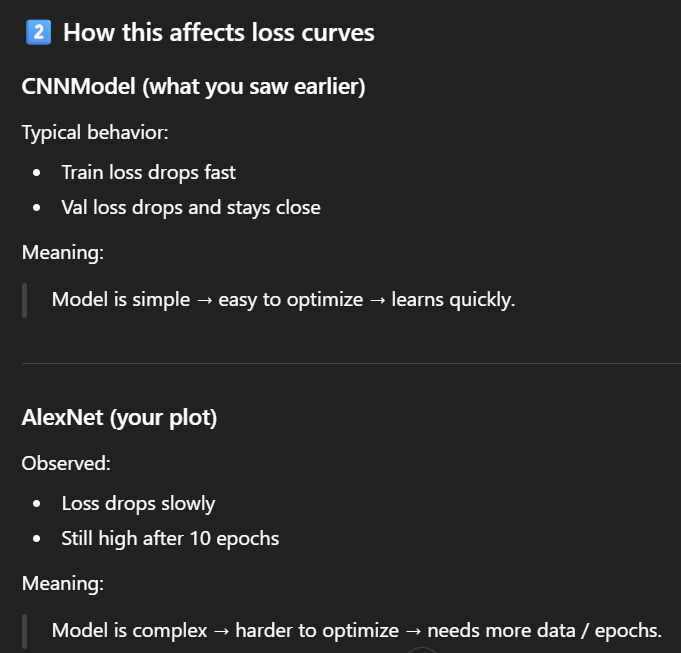

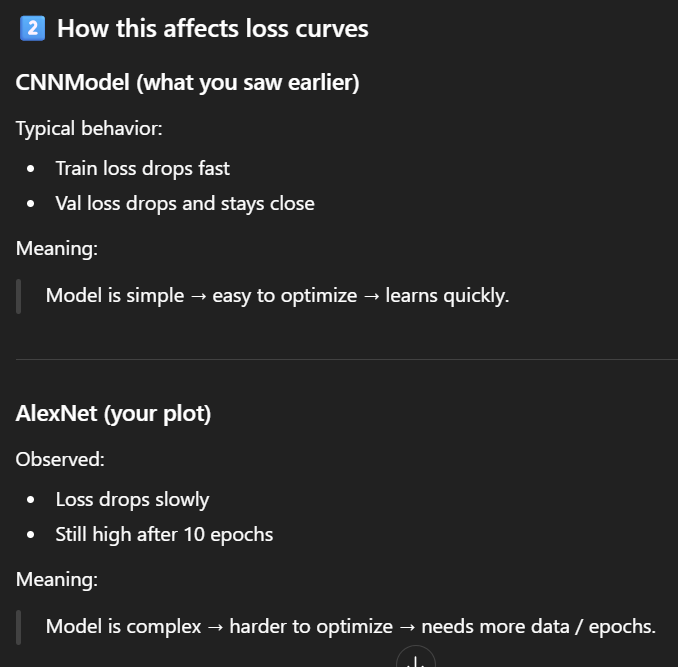

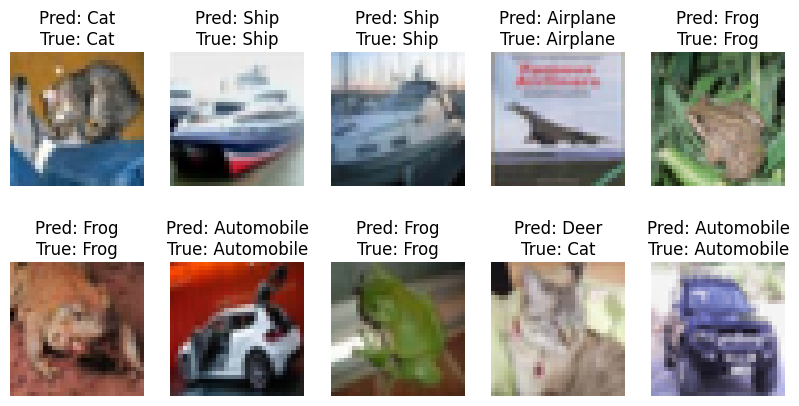

In [ ]:
# Show predictions
show_predictions(modelAlex, test_loader, device)


### Contributed by: Mohamed Eltayeb & Ali Habibullah

![image.png](https://i.imgur.com/a3uAqnb.png)